In [1]:
import yaml

with open("config.base_s_25_elec_Ep100.yaml") as stream:
    try:
        config_original = (yaml.safe_load(stream))
    except yaml.YAMLError as exc:
        print(exc)

In [2]:
solver_options_net = config_original["solving"]["solver_options"]["gurobi-default"]
solver_name = config_original["solving"][("solver")]
solver_name = {'solver_name': "gurobi"}
solver_options = solver_name | solver_options_net
solver_options

{'solver_name': 'gurobi',
 'threads': 32,
 'method': 2,
 'crossover': 0,
 'BarConvTol': 1e-05,
 'Seed': 123,
 'AggFill': 0,
 'PreDual': 0,
 'GURO_PAR_BARDENSETHRESH': 200}

In [3]:
import pypsa
import fbmc  # noqa: F401  not unused; registers pypsa.Network.fbmc accessor
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx


In [4]:
nodal_net = pypsa.Network("base_s_25_elec_Ep100.nc")

nodal_net.buses.rename(columns={"country": "zone_name"}, inplace=True)

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units


In [5]:
nodal_net.generators.p_nom

Generator
BE1 0 CCGT         6634.2
BE1 0 biomass       113.0
BE1 0 nuclear      4096.0
BE1 0 oil           130.2
BE1 0 waste         293.8
                   ...   
GB0 3 0 onwind    11218.9
GB2 0 0 onwind     1231.6
IE2 0 0 onwind     4562.7
LU1 0 0 onwind      133.6
NL1 0 0 onwind     4352.4
Name: p_nom, Length: 256, dtype: float64

In [6]:
nodal_net.buses.loc["DK1 0", "zone_name"] = "DK-10"
nodal_net.buses.loc["DK1 3", "zone_name"] = "DK-13"
nodal_net.buses.loc["DK3 0", "zone_name"] = "DK-30"
nodal_net.buses.loc["GB2 0", "zone_name"] = "NIR"
nodal_net.remove("Bus", "DK1 3")

In [7]:
nodal_net.generators.query('bus == "DK1 3"')
nodal_net.links.query('bus0 == "DK1 3"')

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,p_nom_opt,voltage,underground,under_construction,tags,geometry,dc,underwater_fraction,project_status,reversed
Link,,,,,,,,,,,,,,,,,,,,,


In [8]:
bus_zone_map = nodal_net.buses['zone_name']

In [9]:
bus_zone_map

Bus
BE1 0       BE
DE1 0       DE
DE1 1       DE
DE1 2       DE
DE1 3       DE
DE1 4       DE
DE1 5       DE
DE1 6       DE
DK1 0    DK-10
DK3 0    DK-30
FR1 0       FR
FR1 1       FR
FR1 2       FR
FR1 3       FR
FR1 4       FR
FR1 5       FR
FR1 6       FR
GB0 0       GB
GB0 1       GB
GB0 2       GB
GB0 3       GB
GB2 0      NIR
IE2 0       IE
LU1 0       LU
NL1 0       NL
Name: zone_name, dtype: object

In [10]:
# Cross-zonal links
link_zone0 = nodal_net.links.bus0.map(bus_zone_map)
link_zone1 = nodal_net.links.bus1.map(bus_zone_map)

cross_zone_links = nodal_net.links[link_zone0 != link_zone1]

cross_zone_buses = pd.unique(
    pd.concat([cross_zone_links.bus0, cross_zone_links.bus1])
)

# Create VH buses
for bus in cross_zone_buses:
    vh_bus = f"VH {bus}"

    if vh_bus not in nodal_net.buses.index:
        nodal_net.buses.loc[vh_bus] = nodal_net.buses.loc[bus]

# Save original capacities before rewiring
bus_caps = {}

for bus in cross_zone_buses:
    connected = cross_zone_links[
        (cross_zone_links.bus0 == bus) |
        (cross_zone_links.bus1 == bus)
    ]

    # Assuming capacity column is p_nom
    bus_caps[bus] = connected.p_nom.sum() + 1

bus_map = {bus: f"VH {bus}" for bus in cross_zone_buses}

nodal_net.links.loc[cross_zone_links.index, "bus0"] = (
    nodal_net.links.loc[cross_zone_links.index, "bus0"]
    .replace(bus_map)
)

nodal_net.links.loc[cross_zone_links.index, "bus1"] = (
    nodal_net.links.loc[cross_zone_links.index, "bus1"]
    .replace(bus_map)
)

for bus in cross_zone_buses:
    vh_bus = f"VH {bus}"

    nodal_net.add(
        "Line",
        f"{bus} <-> {vh_bus}",
        bus0=bus,
        bus1=vh_bus,
        s_nom=bus_caps[bus],  # original capacity + 1 MW
        x=0.0001,             # very small reactance
        r=0.0,
    )

vh_mask = nodal_net.buses.index.str.contains("vh", case=False, na=False)

nodal_net.buses.loc[vh_mask, "zone_name"] = nodal_net.buses.index[vh_mask]

In [11]:
nodal_net.buses["zone_name"]

Bus
BE1 0             BE
DE1 0             DE
DE1 1             DE
DE1 2             DE
DE1 3             DE
DE1 4             DE
DE1 5             DE
DE1 6             DE
DK1 0          DK-10
DK3 0          DK-30
FR1 0             FR
FR1 1             FR
FR1 2             FR
FR1 3             FR
FR1 4             FR
FR1 5             FR
FR1 6             FR
GB0 0             GB
GB0 1             GB
GB0 2             GB
GB0 3             GB
GB2 0            NIR
IE2 0             IE
LU1 0             LU
NL1 0             NL
VH FR1 3    VH FR1 3
VH GB0 2    VH GB0 2
VH DK3 0    VH DK3 0
VH DK1 0    VH DK1 0
VH GB2 0    VH GB2 0
VH GB0 1    VH GB0 1
VH BE1 0    VH BE1 0
VH IE2 0    VH IE2 0
VH DE1 4    VH DE1 4
VH GB0 0    VH GB0 0
VH NL1 0    VH NL1 0
VH FR1 6    VH FR1 6
VH DE1 3    VH DE1 3
VH GB0 3    VH GB0 3
VH DE1 0    VH DE1 0
VH FR1 2    VH FR1 2
Name: zone_name, dtype: object

In [12]:
nodal_net.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,v_nom,i_nom,dc
Line,,,,,,,,,,,,,,,,,,,,,
0,BE1 0,DE1 2,Al/St 240/40 4-bundle 380.0,31.843002,3.883293,0.0,0.002245,3396.210000,0.0,True,...,0.000221,0.000027,0.0,0.0,0.000221,0.000027,4853.665269,380.0,2.58,NaN
1,BE1 0,FR1 2,Al/St 240/40 4-bundle 380.0,115.875914,14.131209,0.0,0.000716,1005.455494,0.0,True,...,0.000802,0.000098,0.0,0.0,0.000802,0.000098,1005.456135,380.0,2.58,0.0
10,DE1 0,DK1 0,Al/St 240/40 4-bundle 380.0,32.118103,3.916842,0.0,0.002264,3396.210000,0.0,True,...,0.000222,0.000027,0.0,0.0,0.000222,0.000027,4386.258887,380.0,2.58,NaN
11,DE1 0,DK1 0,Al/St 240/40 4-bundle 380.0,32.118103,3.916842,0.0,0.002264,3396.210000,0.0,True,...,0.000222,0.000027,0.0,0.0,0.000222,0.000027,4386.258092,380.0,2.58,NaN
12,DE1 1,DE1 3,Al/St 240/40 4-bundle 380.0,24.568469,2.996155,0.0,0.006928,6792.410447,0.0,True,...,0.000170,0.000021,0.0,0.0,0.000170,0.000021,6792.450481,380.0,2.58,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FR1 6 <-> VH FR1 6,FR1 6,VH FR1 6,,0.000100,0.000000,0.0,0.000000,3001.000000,0.0,False,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN
DE1 3 <-> VH DE1 3,DE1 3,VH DE1 3,,0.000100,0.000000,0.0,0.000000,601.000000,0.0,False,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN
GB0 3 <-> VH GB0 3,GB0 3,VH GB0 3,,0.000100,0.000000,0.0,0.000000,501.000000,0.0,False,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN


In [13]:
zonal_net = nodal_net.fbmc.to_zonal(bus_zone_map)

In [14]:
config = fbmc.FBMCConfig(
    base_case_strategy=fbmc.BaseCaseStrategy.ZERO_FLOWS,
    add_security_constraints=False,
    gsk_strategy=fbmc.GSKStrategy.P_NOM,
    security_constraint_bodf_size_threshold=0.1,
    min_ram=0.1,
    reliability_margin_factor=0.0,
    advanced_hybrid_coupling_flag= True,
    #solver_kwargs={'solver_name': 'gurobi', 'OutputFlag': 0},
    solver_kwargs=solver_options
)

zonal_net.fbmc.create_model(nodal_net, config=config)

       'relation/15772117-320-DC', 'relation/15781671-525-DC',
       'relation/2127794-270-DC', 'relation/2505320-400-DC',
       'relation/5487095-400-DC', 'relation/6914309-500-DC',
       'relation/8184641-200-DC', 'relation/8185420-320-DC',
       'relation/8185487-400-DC', 'relation/8193755-320-DC', 'TYNDP2020_17',
       'TYNDP2020_32', 'TYNDP2020_36', 'DC2', 'TYNDP2024_153', 'TYNDP2024_285',
       'TYNDP2022_286'],
      dtype='object', name='Link')
INFO:root:Determined 4 sub-networks in the base case nodal network.


branches basecase: <xarray.DataArray 'branch' (branch: 49)> Size: 392B
array(['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
       '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3',
       '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '5',
       '6', '7', '8', '9', 'FR1 3 <-> VH FR1 3', 'DK1 0 <-> VH DK1 0',
       'BE1 0 <-> VH BE1 0', 'DE1 4 <-> VH DE1 4', 'NL1 0 <-> VH NL1 0',
       'FR1 6 <-> VH FR1 6', 'DE1 3 <-> VH DE1 3', 'DE1 0 <-> VH DE1 0',
       'FR1 2 <-> VH FR1 2'], dtype=object)
Coordinates:
  * branch            (branch) object 392B '0' '1' ... 'FR1 2 <-> VH FR1 2'
    branch_component  (branch) object 392B 'Line' 'Line' ... 'Line' 'Line'
branches cnecs: <xarray.DataArray 'branch' (branch: 49)> Size: 392B
array(['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
       '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3',
       '30', '31', '32', '33', '34', '35', '36', '3

KeyError: "not all values found in index 'branch'"

In [92]:
zonal_net.model.variables["Zone-p"][0]

Variable (Zone: 10)
-------------------
[BE]: Zone-p[2013-01-01 00:00:00, BE] ∈ [-inf, inf]
[DE]: Zone-p[2013-01-01 00:00:00, DE] ∈ [-inf, inf]
[DK-10]: Zone-p[2013-01-01 00:00:00, DK-10] ∈ [-inf, inf]
[DK-30]: Zone-p[2013-01-01 00:00:00, DK-30] ∈ [-inf, inf]
[FR]: Zone-p[2013-01-01 00:00:00, FR] ∈ [-inf, inf]
[GB]: Zone-p[2013-01-01 00:00:00, GB] ∈ [-inf, inf]
[IE]: Zone-p[2013-01-01 00:00:00, IE] ∈ [-inf, inf]
[LU]: Zone-p[2013-01-01 00:00:00, LU] ∈ [-inf, inf]
[NIR]: Zone-p[2013-01-01 00:00:00, NIR] ∈ [-inf, inf]
[NL]: Zone-p[2013-01-01 00:00:00, NL] ∈ [-inf, inf]

In [8]:
label = 3057820
var_name, coord = zonal_net.model.variables.get_label_position(label)
print(var_name, coord)

Zone-p {'snapshot': Timestamp('2013-01-01 00:00:00'), 'Zone': 'DK-13'}


In [34]:
zonal_net.model.solve(**config.solver_kwargs)
result = zonal_net.fbmc.results()
print(result)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 32
 - method: 2
 - crossover: 0
 - BarConvTol: 1e-05
 - Seed: 123
 - AggFill: 0
 - PreDual: 0
 - GURO_PAR_BARDENSETHRESH: 200
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 129.81it/s]
INFO:linopy.io: Writing time: 1.39s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2838876


INFO:gurobipy:Set parameter LicenseID to value 2838876


...

INFO:gurobipy:Barrier solved model in 122 iterations and 1331.68 seconds (1601.40 work units)


Optimal objective 3.99802559e+10


INFO:gurobipy:Optimal objective 3.99802559e+10


INFO:gurobipy:
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3145177 primals, 7233772 duals
Objective: 4.00e+10
Solver model: available
Solver message: 2

/Users/ng-work/.pyenv/versions/pypsa-fbmc/lib/python3.11/site-packages/linopy/common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
/Users/ng-work/.pyenv/versions/pypsa-fbmc/lib/python3.11/site-packages/linopy/common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


FBMCResult
  zonal_net: Unnamed Network | snapshots=8736 | components=[Bus:10, Generator:256, Load:25, Link:19, StorageUnit:25]
  base_case: Unnamed Network | snapshots=8736 | components=[Bus:25, Generator:256, Load:25, Line:46, Link:36, StorageUnit:25, SubNetwork:5]
  net_positions: DataFrame(8736, 10)
  dispatch_results: DispatchResult object with attrs: 
  generators_p: (8736, 256) snapshots x generators, 
  storage_units_p: (8736, 25) snapshots x storage units, 
  links_p0: (8736, 19) snapshots x links, 
  storage_levels: (8736, 25) snapshots x storage levels, 
  water_values: (8736, 25) snapshots x water values
  fbmc_parameters: 2 subnet(s) [0, 2]


In [53]:
result.net_positions

<xarray.DataArray 'Zone-p' (snapshot: 8736, Zone: 10)> Size: 699kB
array([[-2.59293908e+03,  1.04191741e+02,  9.65002564e+03, ...,
        -9.34252783e+02,  1.21501897e-06,  3.10004392e+03],
       [-2.01317539e+03,  9.51904488e+01,  7.61489853e+03, ...,
        -8.02993356e+02,  1.21501313e-06,  4.54031051e+03],
       [-1.68127243e+03,  1.00787593e+02,  5.68876955e+03, ...,
        -7.20120434e+02,  1.21659265e-06,  5.87251542e+03],
       ...,
       [-4.28748524e+03,  1.15353242e+03,  1.32987346e+04, ...,
        -5.87342835e+02,  1.21529176e-06,  1.52957569e+03],
       [-5.13364925e+03,  1.85427150e+03,  1.30457278e+04, ...,
        -9.98501337e+02,  1.21652114e-06,  1.96140277e+03],
       [-3.62097668e+03, -8.16252176e+02,  1.39419709e+04, ...,
        -1.23784345e+03,  1.21544768e-06,  2.37367383e+03]])
Coordinates:
  * snapshot  (snapshot) datetime64[ns] 70kB 2013-01-01 ... 2013-12-30T23:00:00
  * Zone      (Zone) <U5 200B 'BE' 'DE' 'DK-10' 'DK-30' ... 'IE' 'LU' 'NIR' 'NL'

In [40]:
nodal_net.buses.index.to_list()

['BE1 0',
 'DE1 0',
 'DE1 1',
 'DE1 2',
 'DE1 3',
 'DE1 4',
 'DE1 5',
 'DE1 6',
 'DK1 0',
 'DK3 0',
 'FR1 0',
 'FR1 1',
 'FR1 2',
 'FR1 3',
 'FR1 4',
 'FR1 5',
 'FR1 6',
 'GB0 0',
 'GB0 1',
 'GB0 2',
 'GB0 3',
 'GB2 0',
 'IE2 0',
 'LU1 0',
 'NL1 0',
 'DK1 3']

In [5]:
result.zonal_net.model.constraints

NameError: name 'result' is not defined

In [35]:
result.zonal_net.model.constraints['CNEC-upper-RAM-subnet-0'].sel(snapshot=zonal_net.snapshots[10]).sel(cnec="2")

Constraint `CNEC-upper-RAM-subnet-0`
------------------------------------
-0.2026 Zone-p[2013-01-01 10:00:00, DE] - 0.1982 Zone-p[2013-01-01 10:00:00, DK-10] - 0.6557 Zone-p[2013-01-01 10:00:00, FR] - 0.1802 Zone-p[2013-01-01 10:00:00, LU] - 0.1254 Zone-p[2013-01-01 10:00:00, NL] ≤ 6168.548327418042

In [36]:
con = result.zonal_net.model.constraints['Zone-definition'].sel(snapshot=zonal_net.snapshots[0]).sel(Zone="BE")
print(str(con))

Constraint `Zone-definition`
----------------------------
+1 Zone-p[2013-01-01 00:00:00, BE] - 1 Generator-p[2013-01-01 00:00:00, BE1 0 CCGT] - 1 Generator-p[2013-01-01 00:00:00, BE1 0 biomass] ... +1 StorageUnit-p_store[2013-01-01 00:00:00, BE1 0 battery] + 1 Link-p[2013-01-01 00:00:00, relation/8193755-320-DC] - 1 Link-p[2013-01-01 00:00:00, relation/8185487-400-DC] = -8096.0000076293945


In [10]:
result.zonal_net.model.constraints['CNEC-lower-RAM-subnet-0'].sel(snapshot=zonal_net.snapshots[0])

Constraint `CNEC-lower-RAM-subnet-0` [cnec: 15]:
------------------------------------------------
[0]: -0.5116 Zone-p[2013-03-01 00:00:00, DE] - 0.5992 Zone-p[2013-03-01 00:00:00, NL]  ≥ -2798.284081149478
[1]: -0.4884 Zone-p[2013-03-01 00:00:00, DE] - 0.4008 Zone-p[2013-03-01 00:00:00, NL]  ≥ -3314.885321116425
[10]: +0.03118 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -4727.512806574352
[11]: +0.07794 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -26193.84472864287
[12]: -0.03624 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -6568.791078020348
[13]: +0.03494 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -6542.823244299205
[14]: -0.5116 Zone-p[2013-03-01 00:00:00, DE] + 0.1362 Zone-p[2013-03-01 00:00:00, NL] ≥ -9552.020435697692
		...
[3]: -0.2697 Zone-p[2013-03-01 00:00:00, DE]                                           ≥ -11238.855601234194
[4]: -0.1454 Zone-p[2013-03-01 

In [139]:
d = nodal_net.buses.apply(lambda row: (row["x"], row["y"]), axis=1).to_dict()
d

{'BE0 0': (5.139284238571429, 50.68561860171428),
 'DE0 0': (7.239637820731708, 51.37830108810975),
 'DE0 1': (11.40887984148936, 48.80724648893617),
 'DE0 2': (13.094428980806452, 52.452413288870964),
 'DE0 3': (9.25141665419355, 53.4362586617742),
 'DE0 4': (8.705499178787878, 49.17755361858586),
 'DE0 5': (10.195867937435898, 51.594052309487175),
 'NL0 0': (4.481626574117647, 52.059696368235294),
 'NL0 1': (6.183861166470588, 52.56340226882353)}

In [140]:
nodal_net.buses[["x","y"]].to_dict(orient = 'index')

{'BE0 0': {'x': 5.139284238571429, 'y': 50.68561860171428},
 'DE0 0': {'x': 7.239637820731708, 'y': 51.37830108810975},
 'DE0 1': {'x': 11.40887984148936, 'y': 48.80724648893617},
 'DE0 2': {'x': 13.094428980806452, 'y': 52.452413288870964},
 'DE0 3': {'x': 9.25141665419355, 'y': 53.4362586617742},
 'DE0 4': {'x': 8.705499178787878, 'y': 49.17755361858586},
 'DE0 5': {'x': 10.195867937435898, 'y': 51.594052309487175},
 'NL0 0': {'x': 4.481626574117647, 'y': 52.059696368235294},
 'NL0 1': {'x': 6.183861166470588, 'y': 52.56340226882353}}

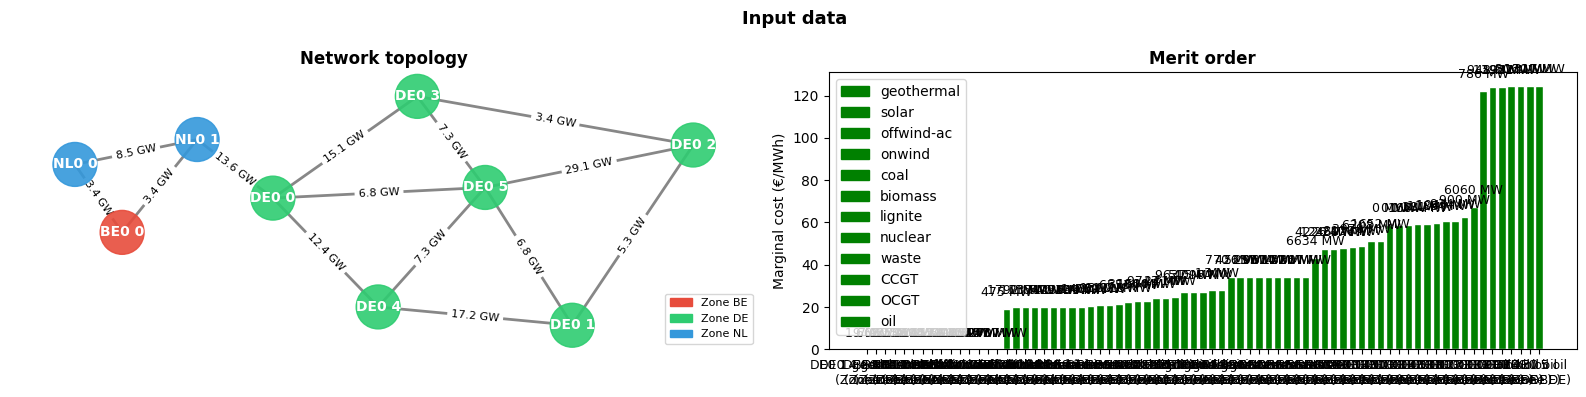

In [8]:
zone_colors   = {'BE': '#E74C3C', 'DE': '#2ECC71', 'NL': '#3498DB'}
carrier_colors = {'CCGT': "green", 'OCGT':"green", 'biomass':"green", 'nuclear':"green", 'oil':"green", 'waste':"green", 'coal':"green", 'lignite':"green", 'geothermal':"green", 'onwind':"green", 'offwind-ac':"green", 'solar':"green"}

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Network topology
ax = axes[0]
#pos = {'A1': (-2, 0), 'B1': (0, 1.2), 'B2': (0, -1.2), 'C1': (2, 0)}
pos = nodal_net.buses.apply(lambda row: (row["x"], row["y"]), axis=1).to_dict()
G = nx.Graph()
G.add_nodes_from(nodal_net.buses.index)
for l in nodal_net.lines.itertuples():
    G.add_edge(l.bus0, l.bus1, s_nom=l.s_nom)

nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=[zone_colors[nodal_net.buses.loc[b, 'zone_name']] for b in G.nodes()],
    node_size=1000, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_weight='bold', font_color='white', font_size=10)
nx.draw_networkx_edges(G, pos, ax=ax,
    width=2, edge_color='#555', alpha=0.7)
nx.draw_networkx_edge_labels(G, pos,
    {(u, v): f"{round(G[u][v]['s_nom']/1000,1)} GW" for u, v in G.edges()}, font_size=8, ax=ax)
ax.legend(handles=[mpatches.Patch(color=c, label=f'Zone {z}') for z, c in zone_colors.items()],
          loc='lower right', fontsize=8)
ax.set_title('Network topology', fontweight='bold')
ax.axis('off')

# Merit order
ax = axes[1]
gens = nodal_net.generators.copy()
gens['zone'] = nodal_net.buses.loc[gens['bus'], 'zone_name'].values
gens = gens.sort_values('marginal_cost')
ax.bar(range(len(gens)), gens['marginal_cost'],
       color=[carrier_colors[c] for c in gens['carrier']], edgecolor='white')
for i, (_, row) in enumerate(gens.iterrows()):
    ax.text(i, row['marginal_cost'] + 6, f"{int(row['p_nom'])} MW", ha='center', fontsize=9)
ax.set_xticks(range(len(gens)))
ax.set_xticklabels([f"{idx}\n(Zone {row['zone']})" for idx, row in gens.iterrows()], fontsize=9)
ax.set_ylabel('Marginal cost (€/MWh)')
ax.set_title('Merit order', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=carrier_colors[c], label=c) for c in gens['carrier'].unique()])


plt.suptitle('Input data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
from fbmc.post_processing.main import process_results

In [39]:
process_results(result, rd_cost= None, rd_dispatch= None, save_path = "/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results", config = config)

INFO:pypsa.network.io:Exported network 'Unnamed Network'saved to '/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results/fbmc_network.nc contains: carriers, buses, loads, storage_units, generators, links


{'zonal_market_prices': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results/zonal_market_prices.csv'),
 'load_shedding_zone_p': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results/load_shedding_zone_p.csv'),
 'generation_mix': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results/generation_mix.csv'),
 'storage_mix': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results/storage_mix.csv'),
 'storage_units_p': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results/storage_units_p.csv'),
 'summary': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results/summary.json'),
 'linopy_model': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results/linopy_model.nc'),
 'net_positions_zone_p': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results/net_positions_zone_p.csv'),
 'fbmc_links_p0': Po

In [10]:
from src.redispatch.main import run_redispatch
redispatch_results = run_redispatch(nodal_net, result.dispatch_results, security_constrained_flag=False)

ValueError: conflicting sizes for dimension 'Generator': length 73 on the data but length 82 on coordinate 'Generator'

In [137]:
nodal_net

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 9
 - Carrier: 16
 - Generator: 82
 - Line: 15
 - Link: 14
 - Load: 9
 - StorageUnit: 9
 - SubNetwork: 1
Snapshots: 24

In [138]:
process_results(result, rd_cost= None, rd_dispatch= None, save_path = "/Users/ng-work/Models/pypsa-fbmc/nathan_tests/3-zones/results", config = config)

NameError: name 'process_results' is not defined

In [24]:
nodal_net.buses_t.p.sum().sum()/nodal_net.loads_t.p.sum().sum()

9.571911139049392e-08

In [28]:
nodal_net.buses_t.p.sum(axis=1).max()

0.02457689493530779

In [19]:
nodal_net.statistics.energy_balance(groupby="bus").groupby("component").sum()

component
Generator      1.578752e+09
Line           7.450581e-09
Link           0.000000e+00
Load          -1.576725e+09
StorageUnit   -2.026875e+06
dtype: float64

In [23]:
nodal_net.loads_t.p.sum().sum()

1576724603.6762848

In [42]:
zonal_net.buses_t.marginal_price

Bus
snapshot
2013-01-01 00:00:00
2013-01-01 01:00:00
2013-01-01 02:00:00
2013-01-01 03:00:00
2013-01-01 04:00:00
...
2013-12-30 19:00:00
2013-12-30 20:00:00
2013-12-30 21:00:00


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x38c32a0d0>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x38c37b090>,
  'Link': <matplotlib.collections.LineCollection at 0x38c531490>},
 'flows': {}}

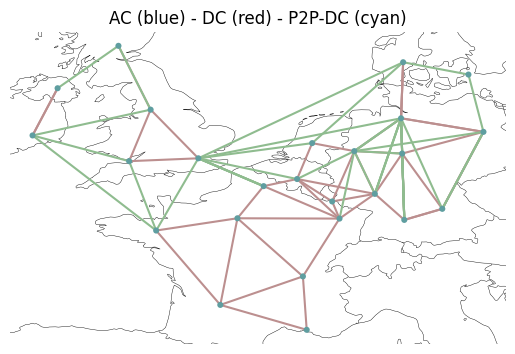

In [54]:
import cartopy
line_color = nodal_net.lines.bus0.map(nodal_net.buses.carrier).map(
    lambda ct: "r" if ct == "DC" else "b"
)

nodal_net.plot.map(
    title="AC (blue) - DC (red) - P2P-DC (cyan)",
    jitter=0.4,
)

In [63]:
result.zonal_net.model

Linopy LP model

Variables:
----------
 * Generator-p_nom (Generator-ext)
 * Link-p_nom (Link-ext)
 * StorageUnit-p_nom (StorageUnit-ext)
 * Generator-p (snapshot, Generator)
 * Link-p (snapshot, Link)
 * StorageUnit-p_dispatch (snapshot, StorageUnit)
 * StorageUnit-p_store (snapshot, StorageUnit)
 * StorageUnit-state_of_charge (snapshot, StorageUnit)
 * objective_constant
 * Zone-p (snapshot, Zone)

Constraints:
------------
 * Generator-ext-p_nom-lower (Generator-ext)
 * Generator-ext-p_nom-upper (Generator-ext)
 * Link-ext-p_nom-lower (Link-ext)
 * Link-ext-p_nom-upper (Link-ext)
 * StorageUnit-ext-p_nom-lower (StorageUnit-ext)
 * StorageUnit-ext-p_nom-upper (StorageUnit-ext)
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Generator-ext-p-lower (snapshot, Generator-ext)
 * Generator-ext-p-upper (snapshot, Generator-ext)
 * Link-ext-p-lower (snapshot, Link-ext)
 * Link-ext-p-upper (snapshot, Link-ext)
 * StorageUnit-ext-p_dispa

In [129]:
result.zonal_net.model.constraints["Bus-nodal_balance"].dual.to_pandas()

snapshot,2013-01-01 00:00:00,2013-01-01 01:00:00,2013-01-01 02:00:00,2013-01-01 03:00:00,2013-01-01 04:00:00,2013-01-01 05:00:00,2013-01-01 06:00:00,2013-01-01 07:00:00,2013-01-01 08:00:00,2013-01-01 09:00:00,...,2013-12-30 14:00:00,2013-12-30 15:00:00,2013-12-30 16:00:00,2013-12-30 17:00:00,2013-12-30 18:00:00,2013-12-30 19:00:00,2013-12-30 20:00:00,2013-12-30 21:00:00,2013-12-30 22:00:00,2013-12-30 23:00:00
Bus,,,,,,,,,,,,,,,,,,,,,
DK-30,0.024929,0.024777,0.024706,0.024675,0.024753,0.025015,0.025739,0.028008,0.037812,0.287076,...,0.039860,0.043729,0.042963,0.041670,0.038567,0.036515,0.035989,0.035534,0.035092,0.025032
IE,7.462453,0.061197,0.048709,0.044513,0.043155,0.042399,0.041036,0.031071,0.036126,0.040732,...,27.335527,76.452203,76.451448,76.448319,27.363518,27.333024,26.910996,0.027738,0.025491,0.025411
NIR,7.444037,2.733186,0.029024,0.025908,0.025544,0.025363,0.025295,0.025076,0.025141,0.025350,...,27.305892,27.332835,76.279562,76.279274,76.279971,28.450344,27.314239,27.312502,2.590787,0.027098


snapshot
2013-01-01 00:00:00    2956.563753
2013-01-01 01:00:00    2889.274115
2013-01-01 02:00:00    2540.535517
2013-01-01 03:00:00    2429.898050
2013-01-01 04:00:00    2517.828203
                          ...     
2013-12-30 19:00:00    3585.700347
2013-12-30 20:00:00    4018.395614
2013-12-30 21:00:00    4189.748155
2013-12-30 22:00:00    3956.024408
2013-12-30 23:00:00    3884.614269
Name: IE2 0 0 onwind, Length: 8736, dtype: float64

In [132]:
result.zonal_net.model.constraints["Zone-definition"].dual.to_pandas

<bound method DataArray.to_pandas of <xarray.DataArray 'dual' (snapshot: 8736, Zone: 10)> Size: 699kB
array([[-7.46652178e+00, -2.46791654e-02, -2.54185064e-02, ...,
        -7.31266502e-01,  0.00000000e+00, -2.75781831e+00],
       [-7.46643021e+00, -2.46383266e-02, -2.54038174e-02, ...,
        -7.31689261e-01,  0.00000000e+00, -2.75757988e+00],
       [-7.46645421e+00, -2.46248843e-02, -2.55077356e-02, ...,
        -7.32127716e-01,  0.00000000e+00, -2.75764224e+00],
       ...,
       [-2.73319579e+01, -9.49025043e+00, -2.59381507e-02, ...,
        -7.32481639e-01,  0.00000000e+00, -9.93645135e+00],
       [-1.99989615e+01, -6.34914325e+00, -2.57651384e-02, ...,
        -7.31297278e-01,  0.00000000e+00, -1.03553969e+01],
       [-1.22227691e+01, -2.74534449e-02, -2.58365346e-02, ...,
        -7.30369196e-01,  0.00000000e+00, -4.53584100e+00]])
Coordinates:
  * snapshot  (snapshot) datetime64[ns] 70kB 2013-01-01 ... 2013-12-30T23:00:00
  * Zone      (Zone) <U5 200B 'BE' 'DE' 'DK-10' 

In [64]:
result.zonal_net.model.variables["Zone-p"]

Variable (snapshot: 8736, Zone: 10)
-----------------------------------
[2013-01-01 00:00:00, BE]: Zone-p[2013-01-01 00:00:00, BE] ∈ [-inf, inf]
[2013-01-01 00:00:00, DE]: Zone-p[2013-01-01 00:00:00, DE] ∈ [-inf, inf]
[2013-01-01 00:00:00, DK-10]: Zone-p[2013-01-01 00:00:00, DK-10] ∈ [-inf, inf]
[2013-01-01 00:00:00, DK-30]: Zone-p[2013-01-01 00:00:00, DK-30] ∈ [-inf, inf]
[2013-01-01 00:00:00, FR]: Zone-p[2013-01-01 00:00:00, FR] ∈ [-inf, inf]
[2013-01-01 00:00:00, GB]: Zone-p[2013-01-01 00:00:00, GB] ∈ [-inf, inf]
[2013-01-01 00:00:00, IE]: Zone-p[2013-01-01 00:00:00, IE] ∈ [-inf, inf]
		...
[2013-12-30 23:00:00, DK-30]: Zone-p[2013-12-30 23:00:00, DK-30] ∈ [-inf, inf]
[2013-12-30 23:00:00, FR]: Zone-p[2013-12-30 23:00:00, FR] ∈ [-inf, inf]
[2013-12-30 23:00:00, GB]: Zone-p[2013-12-30 23:00:00, GB] ∈ [-inf, inf]
[2013-12-30 23:00:00, IE]: Zone-p[2013-12-30 23:00:00, IE] ∈ [-inf, inf]
[2013-12-30 23:00:00, LU]: Zone-p[2013-12-30 23:00:00, LU] ∈ [-inf, inf]
[2013-12-30 23:00:00, NIR]: 

In [111]:
result.zonal_net.statistics.expanded_capacity()

component    carrier                 
Generator    Combined-Cycle Gas               0.89296
             Offshore Wind (AC)               1.34084
             Offshore Wind (DC)               4.58522
             Offshore Wind (Floating)         3.49939
             Onshore Wind                 38837.28688
             Open-Cycle Gas                   0.10507
             Solar                        19085.71321
             biomass                          0.00000
             coal                             0.00000
             geothermal                       0.00000
             lignite                          0.00000
             nuclear                          0.42779
             oil                              0.00000
             solar-hsat                  135482.99670
             waste                            0.00000
Link         DC                               3.68863
StorageUnit  Battery Storage              26355.85776
dtype: float64

In [128]:
result.zonal_net.model.constraints["Generator-ext-p-upper"]

Constraint `Generator-ext-p-upper` [snapshot: 8736, Generator-ext: 172]:
------------------------------------------------------------------------
[2013-01-01 00:00:00, BE1 0 CCGT]: +1 Generator-p[2013-01-01 00:00:00, BE1 0 CCGT] - 1 Generator-p_nom[BE1 0 CCGT]                  ≤ -0.0
[2013-01-01 00:00:00, BE1 0 nuclear]: +1 Generator-p[2013-01-01 00:00:00, BE1 0 nuclear] - 0.781 Generator-p_nom[BE1 0 nuclear]     ≤ -0.0
[2013-01-01 00:00:00, DE1 0 CCGT]: +1 Generator-p[2013-01-01 00:00:00, DE1 0 CCGT] - 1 Generator-p_nom[DE1 0 CCGT]                  ≤ -0.0
[2013-01-01 00:00:00, DE1 0 OCGT]: +1 Generator-p[2013-01-01 00:00:00, DE1 0 OCGT] - 1 Generator-p_nom[DE1 0 OCGT]                  ≤ -0.0
[2013-01-01 00:00:00, DE1 1 CCGT]: +1 Generator-p[2013-01-01 00:00:00, DE1 1 CCGT] - 1 Generator-p_nom[DE1 1 CCGT]                  ≤ -0.0
[2013-01-01 00:00:00, DE1 1 OCGT]: +1 Generator-p[2013-01-01 00:00:00, DE1 1 OCGT] - 1 Generator-p_nom[DE1 1 OCGT]                  ≤ -0.0
[2013-01-01 00:00:00

In [117]:
nodal_net.statistics.expanded_capacity()

component    carrier                 
Generator    Combined-Cycle Gas               0.89296
             Offshore Wind (AC)               1.34084
             Offshore Wind (DC)               4.58522
             Offshore Wind (Floating)         3.49939
             Onshore Wind                 38837.28688
             Open-Cycle Gas                   0.10507
             Solar                        19085.71321
             biomass                          0.00000
             coal                             0.00000
             geothermal                       0.00000
             lignite                          0.00000
             nuclear                          0.42779
             oil                              0.00000
             solar-hsat                  135482.99670
             waste                            0.00000
Line         AC                           85080.20262
Link         DC                              14.58120
StorageUnit  Battery Storage              26

In [118]:
result.zonal_net.statistics.expanded_capacity()

component    carrier                 
Generator    Combined-Cycle Gas               0.89296
             Offshore Wind (AC)               1.34084
             Offshore Wind (DC)               4.58522
             Offshore Wind (Floating)         3.49939
             Onshore Wind                 38837.28688
             Open-Cycle Gas                   0.10507
             Solar                        19085.71321
             biomass                          0.00000
             coal                             0.00000
             geothermal                       0.00000
             lignite                          0.00000
             nuclear                          0.42779
             oil                              0.00000
             solar-hsat                  135482.99670
             waste                            0.00000
Link         DC                               3.68863
StorageUnit  Battery Storage              26355.85776
dtype: float64